In [ ]:
# Data Handling
import numpy as np
import pandas as pd
import os
from pathlib import Path
import glob
import pickle

# API: CPCB and OpenMeteo
import requests
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso,ElasticNet, RidgeCV, LassoCV, ElasticNetCV
import sklearn.linear_model as lm
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Statsmodels
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
month_map = {'January':1,'February':2,'March':3,'April':4,
             'May':5,'June':6,'July':7,'August':8,
             'September':9,'October':10,'November':11,'December':12}

files = [f for f in glob.glob('data/*_*.xlsx')
         if os.path.basename(f).split('_')[0] in month_map]  # ← [0] + basename

all_dfs = []
for f in files:
    parts = os.path.basename(f).replace('.xlsx','').split('_')  # ← basename first
    month_name = parts[0]
    year = int(parts[1])
    
    temp = pd.read_excel(f)
    hour_cols = [c for c in temp.columns if c != 'Date']
    
    temp['AQI'] = temp[hour_cols].mean(axis=1)
    temp['date'] = pd.to_datetime(
        dict(year=year, month=month_map[month_name], day=temp['Date']),
        errors='coerce'
    )
    all_dfs.append(temp[['date','AQI']].dropna())

df_all = pd.concat(all_dfs, ignore_index=True).sort_values('date').reset_index(drop=True)
print(f'Total records: {df_all.shape}')

Total records: (1461, 2)


In [3]:
df_model = df_all.copy()

# Lag features
df_model['AQI_lag1']  = df_model['AQI'].shift(1)
df_model['AQI_lag2']  = df_model['AQI'].shift(2)
df_model['AQI_lag7']  = df_model['AQI'].shift(7)
df_model['AQI_roll7'] = df_model['AQI'].shift(1).rolling(7).mean()

# Date features
df_model['month']      = df_model['date'].dt.month
df_model['dayofweek']  = df_model['date'].dt.dayofweek

# Season: Winter=0, Summer=1, Monsoon=2, Autumn=3
def get_season(month):
    if month in [12, 1, 2]:      return 0  # Winter
    elif month in [3, 4, 5]:     return 1  # Summer
    elif month in [6, 7, 8]:     return 2  # Monsoon
    else:                        return 3  # Autumn

df_model['season'] = df_model['month'].apply(get_season)

# Target variable
df_model['AQI_next'] = df_model['AQI'].shift(-1)
df_model = df_model.dropna().reset_index(drop=True)
print(f'df_model shape: {df_model.shape}')

df_model shape: (1453, 10)


In [4]:
df_model.head()

,date,AQI,AQI_lag1,AQI_lag2,AQI_lag7,AQI_roll7,month,dayofweek,season,AQI_next
0,2022-01-08,154.458333,185.500000,189.583333,173.125000,176.869048,1,5,0,97.833333
1,2022-01-09,97.833333,154.458333,185.500000,152.000000,174.202381,1,6,0,74.333333
2,2022-01-10,74.333333,97.833333,154.458333,154.000000,166.464286,1,0,0,123.666667
3,2022-01-11,123.666667,74.333333,97.833333,175.708333,155.083333,1,1,0,134.208333
4,2022-01-12,134.208333,123.666667,74.333333,208.166667,147.648810,1,2,0,162.333333


In [5]:
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': 19.07,
    'longitude': 72.87,
    'start_date': '2022-01-01',
    'end_date': '2025-12-31',
    'daily': ['temperature_2m_mean', 'precipitation_sum',
              'windspeed_10m_max', 'relative_humidity_2m_mean'],
    'timezone': 'Asia/Kolkata'
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
daily = response.Daily()
n = daily.Variables(0).ValuesAsNumpy().shape[0]

weather_df = pd.DataFrame({
    'date':          pd.date_range(start='2022-01-01', periods=n, freq='D'),
    'temp':          daily.Variables(0).ValuesAsNumpy(),
    'precipitation': daily.Variables(1).ValuesAsNumpy(),
    'windspeed':     daily.Variables(2).ValuesAsNumpy(),
    'humidity':      daily.Variables(3).ValuesAsNumpy(),
})

# Merge weather into df_model on date
df_model = df_model.merge(weather_df, on='date', how='left')
print(f'Shape after merge: {df_model.shape}')
print(f'Null values: {df_model.isnull().sum().sum()}')

Shape after merge: (1453, 14)
Null values: 0


In [6]:
df_model.head()

,date,AQI,AQI_lag1,AQI_lag2,AQI_lag7,AQI_roll7,month,dayofweek,season,AQI_next,temp,precipitation,windspeed,humidity
0,2022-01-08,154.458333,185.500000,189.583333,173.125000,176.869048,1,5,0,97.833333,22.489584,2.3,12.101570,85.468994
1,2022-01-09,97.833333,154.458333,185.500000,152.000000,174.202381,1,6,0,74.333333,21.654165,0.0,21.980644,57.936008
2,2022-01-10,74.333333,97.833333,154.458333,154.000000,166.464286,1,0,0,123.666667,19.625000,0.0,23.065300,56.553085
3,2022-01-11,123.666667,74.333333,97.833333,175.708333,155.083333,1,1,0,134.208333,19.600000,0.0,15.192682,72.075386
4,2022-01-12,134.208333,123.666667,74.333333,208.166667,147.648810,1,2,0,162.333333,20.735416,0.0,18.448023,67.947678


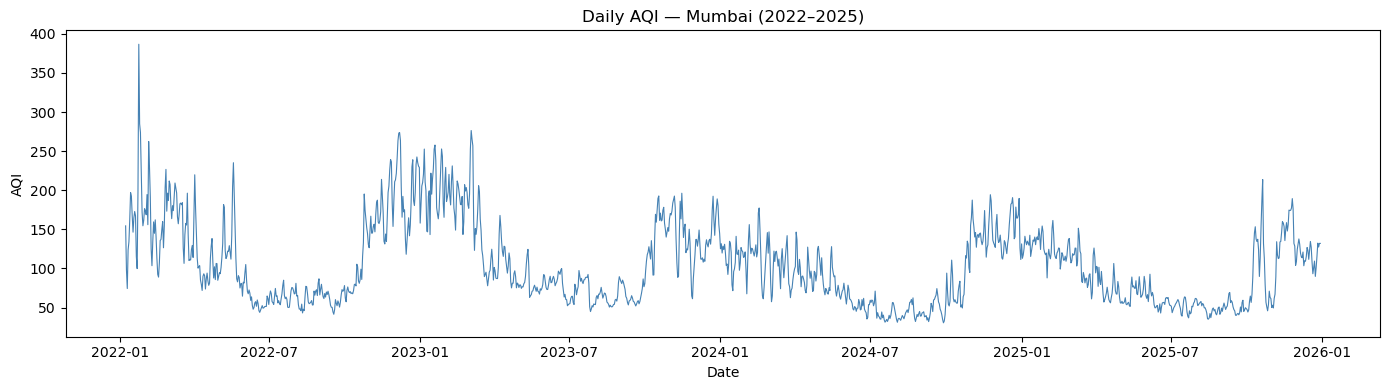

In [7]:
# AQI trend over 4 years

plt.figure(figsize=(14,4))
plt.plot(df_model['date'], df_model['AQI'], linewidth=0.8, color='steelblue')
plt.title('Daily AQI — Mumbai (2022–2025)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

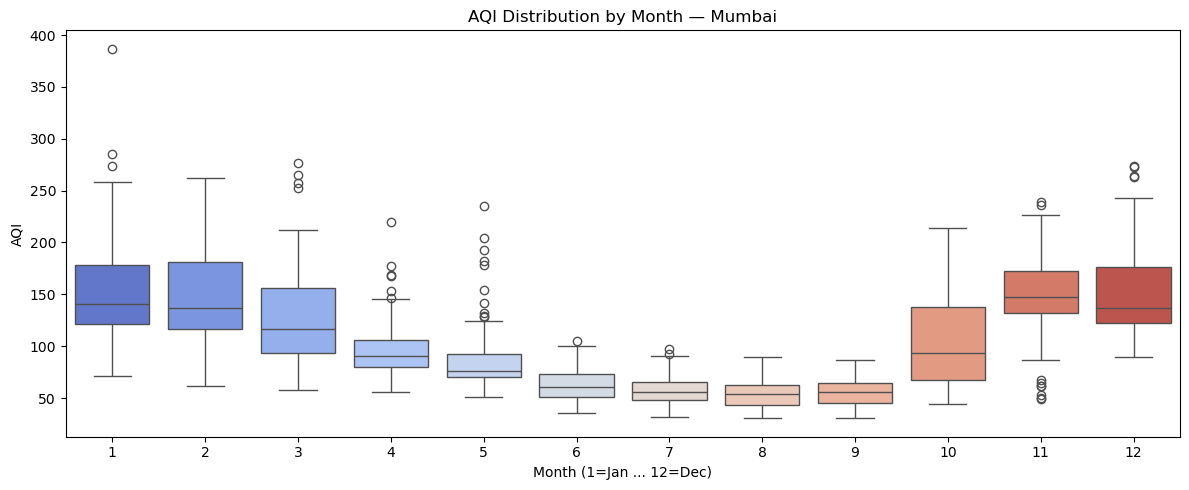

In [8]:
# Monthly boxplot

plt.figure(figsize=(12,5))
sns.boxplot(x='month', y='AQI', data=df_model, palette='coolwarm')
plt.title('AQI Distribution by Month — Mumbai')
plt.xlabel('Month (1=Jan ... 12=Dec)')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

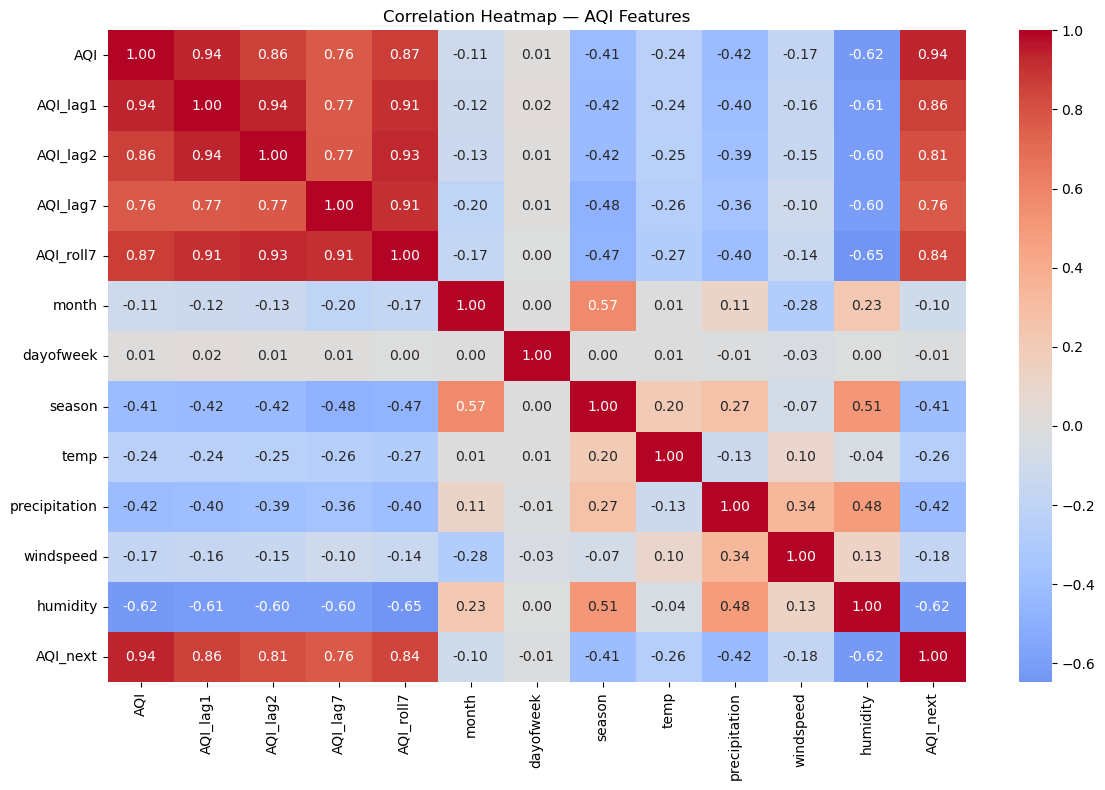

In [9]:
# Correlation heatmap
features = ['AQI','AQI_lag1','AQI_lag2','AQI_lag7','AQI_roll7',
            'month','dayofweek','season',
            'temp','precipitation','windspeed','humidity','AQI_next']
plt.figure(figsize=(12,8))
sns.heatmap(df_model[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — AQI Features')
plt.tight_layout()
plt.show()


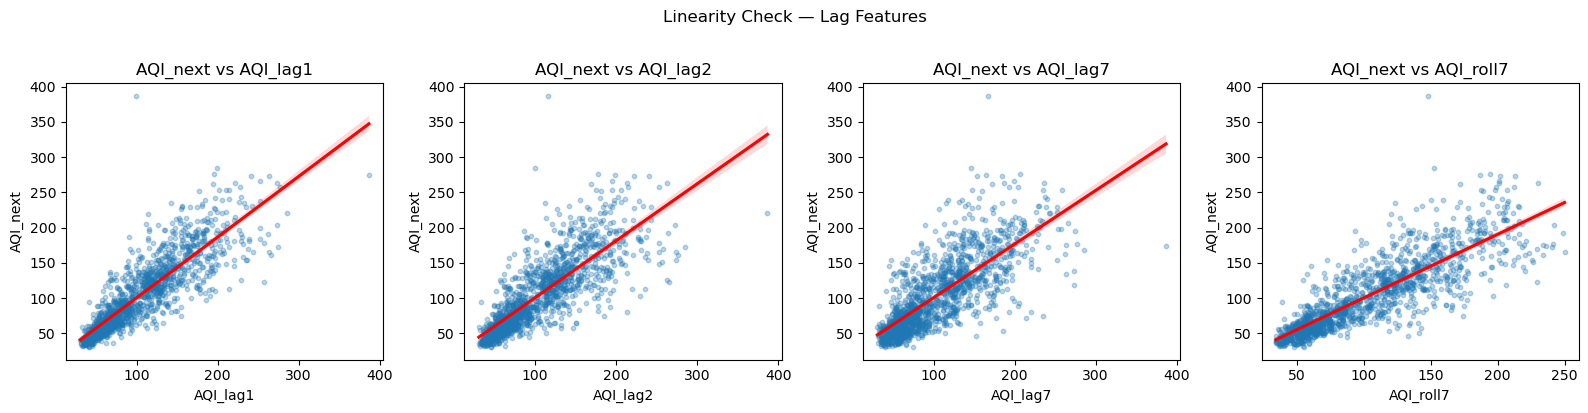

In [10]:
# Regplots — lag features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['AQI_lag1','AQI_lag2','AQI_lag7','AQI_roll7']):
    sns.regplot(x=df_model[col], y=df_model['AQI_next'], ax=ax,
                scatter_kws={'alpha':0.3,'s':10}, line_kws={'color':'red'})
    ax.set_title(f'AQI_next vs {col}')
plt.suptitle('Linearity Check — Lag Features', y=1.02)
plt.tight_layout()
plt.show()

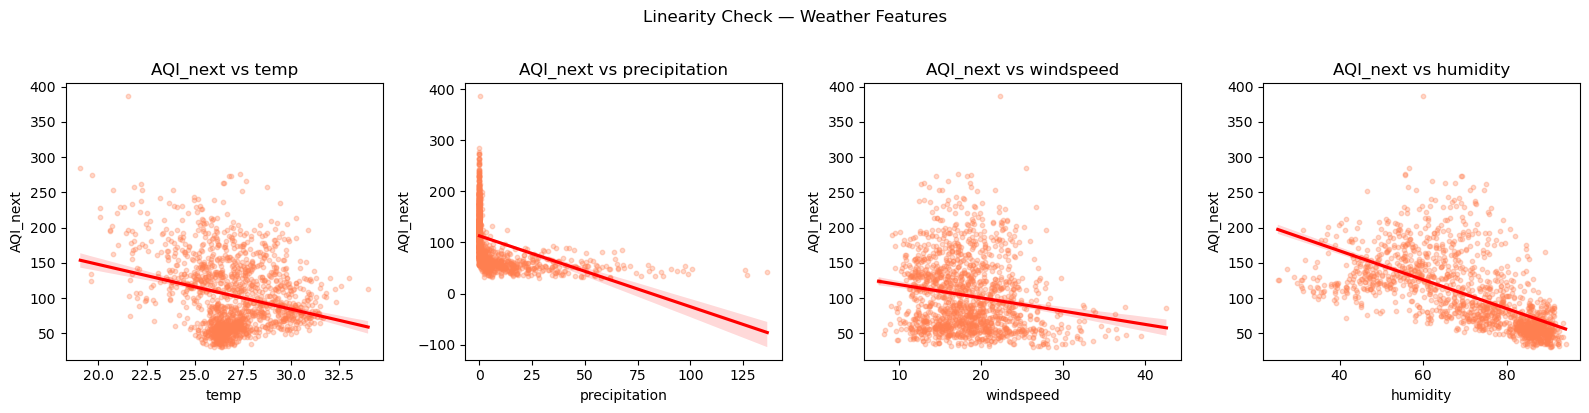

In [11]:
# Regplots — weather features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['temp','precipitation','windspeed','humidity']):
    sns.regplot(x=df_model[col], y=df_model['AQI_next'], ax=ax,
                scatter_kws={'alpha':0.3,'s':10,'color':'coral'}, line_kws={'color':'red'})
    ax.set_title(f'AQI_next vs {col}')
plt.suptitle('Linearity Check — Weather Features', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
continuous_features = ['AQI_lag1','AQI_lag2','AQI_lag7','AQI_roll7','temp','precipitation','windspeed','humidity']

for col in continuous_features:
    df_model[f'{col}_2'] = df_model[col].values ** 2
    formula = f'AQI_next ~ {col} + {col}_2'
    lm_fit = smf.ols(formula, df_model).fit()
    print(lm_fit.summary())

                            OLS Regression Results                            
Dep. Variable:               AQI_next   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     2219.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:23:39   Log-Likelihood:                -6766.0
No. Observations:                1453   AIC:                         1.354e+04
Df Residuals:                    1450   BIC:                         1.355e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.6423      2.897     -2.293      0.0

In [13]:
df_model.shape

(1453, 22)

In [14]:
base_features = [
    'AQI_lag1', 'AQI_lag2', 'AQI_lag7', 'AQI_roll7',
    'temp', 'humidity', 'windspeed', 'precipitation', 'dayofweek','season'
]

aqi_related_cols = ['AQI_lag1', 'AQI_lag2', 'AQI_lag7', 'AQI_roll7']
for col in aqi_related_cols:
    df_model[col] = np.log1p(df_model[col])

feature_cols = base_features
print('Final features:', feature_cols)

X = df_model[feature_cols]
Y = np.log1p(df_model['AQI_next'])

Final features: ['AQI_lag1', 'AQI_lag2', 'AQI_lag7', 'AQI_roll7', 'temp', 'humidity', 'windspeed', 'precipitation', 'dayofweek', 'season']


In [15]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')

X shape: (1453, 10)
Y shape: (1453,)


In [16]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))

         feature        VIF
0      AQI_roll7  37.130208
1       AQI_lag2  21.233330
2       AQI_lag1  12.537285
3       AQI_lag7  10.771631
4       humidity   2.424851
5  precipitation   1.599374
6         season   1.597657
7           temp   1.251810
8      windspeed   1.233682
9      dayofweek   1.009782


In [17]:
fitR=Ridge(alpha=100)
fitR.fit(X,Y)
fitR.coef_
print(pd.Series(fitR.coef_,index=X.columns))

AQI_lag1         0.208996
AQI_lag2         0.035527
AQI_lag7         0.053105
AQI_roll7        0.077740
temp            -0.028672
humidity        -0.061449
windspeed       -0.005177
precipitation   -0.048343
dayofweek       -0.014132
season           0.012358
dtype: float64


In [18]:
fitL=Lasso(alpha=100)
fitL.fit(X,Y)
fitL.coef_
print(pd.Series(fitL.coef_,index=X.columns))

AQI_lag1         0.0
AQI_lag2         0.0
AQI_lag7         0.0
AQI_roll7        0.0
temp            -0.0
humidity        -0.0
windspeed       -0.0
precipitation   -0.0
dayofweek       -0.0
season          -0.0
dtype: float64


In [19]:
fitE=ElasticNet(alpha=100)
fitE.fit(X,Y)
fitE.coef_
print(pd.Series(fitE.coef_,index=X.columns))

AQI_lag1         0.0
AQI_lag2         0.0
AQI_lag7         0.0
AQI_roll7        0.0
temp            -0.0
humidity        -0.0
windspeed       -0.0
precipitation   -0.0
dayofweek       -0.0
season          -0.0
dtype: float64


In [20]:
alphas = 10**np.linspace(10,-5,100)*0.5
ridge= Ridge()
coefs=[]

for a in alphas:
  ridge.set_params(alpha=a)
  ridge.fit(X,Y)
  coefs.append(ridge.coef_)

np.shape(coefs)

(100, 10)

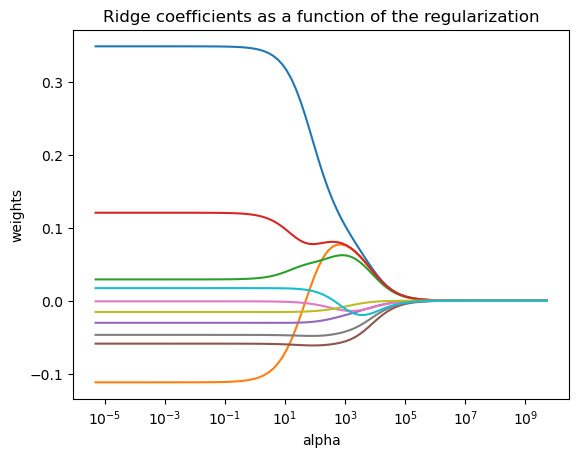

In [21]:
ax=plt.gca()
ax.plot(alphas,coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Ridge coefficients as a function of the regularization')
plt.show()

In [22]:
alphas = 10**np.linspace(10,-5,100)*0.5
lasso= Lasso()
coefs=[]

for a in alphas:
  lasso.set_params(alpha=a)
  lasso.fit(X,Y)
  coefs.append(lasso.coef_)

np.shape(coefs)

(100, 10)

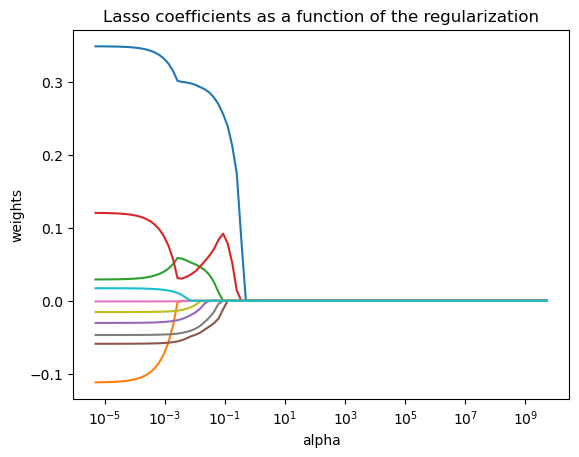

In [23]:
ax=plt.gca()
ax.plot(alphas,coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Lasso coefficients as a function of the regularization')
plt.show()

In [24]:
alphas = 10**np.linspace(10,-5,100)*0.5
EN= ElasticNet()
coefs=[]

for a in alphas:
  EN.set_params(alpha=a)
  EN.fit(X,Y)
  coefs.append(EN.coef_)

np.shape(coefs)

(100, 10)

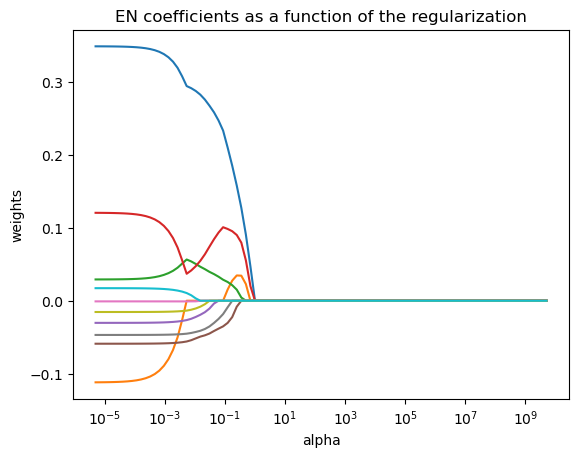

In [25]:
ax=plt.gca()
ax.plot(alphas,coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('EN coefficients as a function of the regularization')
plt.show()

In [26]:
ridgecv=RidgeCV(alphas=alphas)
ridgecv.fit(X,Y)
best_alpha_ridge = ridgecv.alpha_

lassocv=LassoCV(alphas=alphas)
lassocv.fit(X,Y)
best_alpha_lasso = lassocv.alpha_

elasticNet = ElasticNetCV(alphas=alphas)
elasticNet.fit(X, Y)
best_alpha_elasticnet = elasticNet.alpha_

In [27]:
fitR = Ridge(alpha=best_alpha_ridge)
fitR.fit(X,Y)
fitR.coef_
print(pd.Series(fitR.coef_,index=X.columns))

AQI_lag1         0.344268
AQI_lag2        -0.105025
AQI_lag7         0.031164
AQI_roll7        0.116241
temp            -0.030390
humidity        -0.059158
windspeed       -0.000993
precipitation   -0.047041
dayofweek       -0.015486
season           0.017187
dtype: float64


In [28]:
fitL = Lasso(alpha=best_alpha_lasso)
fitL.fit(X,Y)
fitL.coef_
print(pd.Series(fitL.coef_,index=X.columns))

AQI_lag1         0.348280
AQI_lag2        -0.110339
AQI_lag7         0.029641
AQI_roll7        0.119263
temp            -0.030316
humidity        -0.058934
windspeed       -0.000896
precipitation   -0.046922
dayofweek       -0.015446
season           0.017123
dtype: float64


In [29]:
fitE = ElasticNet(alpha=best_alpha_elasticnet)
fitE.fit(X,Y)
fitE.coef_
print(pd.Series(fitE.coef_,index=X.columns))

AQI_lag1         0.348788
AQI_lag2        -0.111554
AQI_lag7         0.029301
AQI_roll7        0.120282
temp            -0.030358
humidity        -0.058972
windspeed       -0.000899
precipitation   -0.046943
dayofweek       -0.015465
season           0.017196
dtype: float64


In [30]:
df_ols = X.copy()
df_ols['AQI_next'] = Y.values

formula = 'AQI_next ~ ' + ' + '.join(feature_cols)
fit = smf.ols(formula, data=df_ols).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:               AQI_next   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     765.7
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:23:45   Log-Likelihood:                 325.10
No. Observations:                1453   AIC:                            -628.2
Df Residuals:                    1442   BIC:                            -570.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.5322      0.005    889.601

In [31]:
results = []
for name, model in [('Linear', fit), ('Ridge', fitR), ('Lasso', fitL),('ElasticNet',fitE)]:
    pred = model.predict(X)
    results.append({
        'Model': name,
        'R2':   round(r2_score(Y, pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(Y, pred)), 2),
        'MAE':  round(mean_absolute_error(Y, pred), 2)
    })

print(pd.DataFrame(results).to_string(index=False))

     Model     R2  RMSE  MAE
    Linear 0.8415  0.19 0.15
     Ridge 0.8415  0.19 0.15
     Lasso 0.8415  0.19 0.15
ElasticNet 0.8415  0.19 0.15


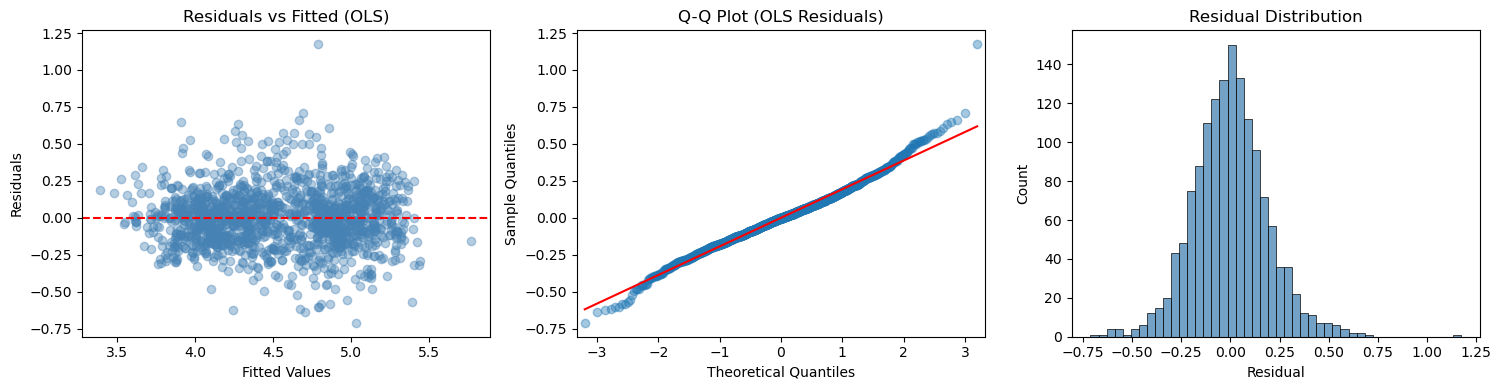

In [32]:
pred_ols = fit.predict(X) 
residuals = Y.values - pred_ols

fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].scatter(pred_ols, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (OLS)')


sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot (OLS Residuals)')


sns.histplot(residuals, ax=axes[2], color='steelblue')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()

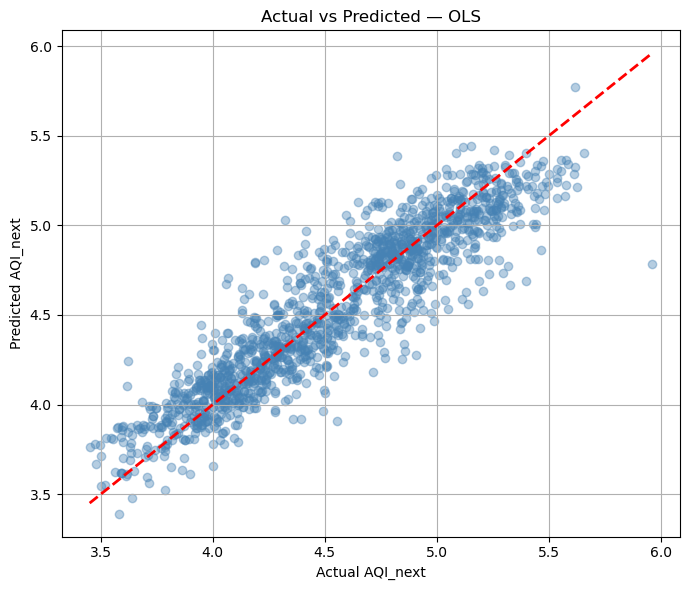

In [33]:
pred_ols = fit.predict(X)

plt.figure(figsize=(7,6))
plt.scatter(Y, pred_ols, alpha=0.4, color='steelblue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel('Actual AQI_next')
plt.ylabel('Predicted AQI_next')
plt.title('Actual vs Predicted — OLS')
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
weather_url = "https://api.open-meteo.com/v1/forecast"
weather_params = {
    "latitude": 19.07,
    "longitude": 72.87,
    "daily": ["temperature_2m_mean", "precipitation_sum",
              "windspeed_10m_max", "relative_humidity_2m_mean"],
    "timezone": "Asia/Kolkata",
    "forecast_days": 1
}
wr = requests.get(weather_url, params=weather_params).json()

today_temp    = wr["daily"]["temperature_2m_mean"][0]
today_precip  = wr["daily"]["precipitation_sum"][0]
today_wind    = wr["daily"]["windspeed_10m_max"][0]
today_humidity= wr["daily"]["relative_humidity_2m_mean"][0]

print(f"Today's weather — Temp: {today_temp}°C, Rain: {today_precip}mm, Wind: {today_wind}km/h, Humidity: {today_humidity}%")

Today's weather — Temp: 28.5°C, Rain: 0.0mm, Wind: 15.9km/h, Humidity: 77%


In [35]:
API_KEY = '579b464db66ec23bdd000001af2dae7288454bc7700cb29a81207cb2'
url = 'https://api.data.gov.in/resource/3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69'
params = {'api-key': API_KEY, 'format': 'json', 'limit': 500, 'filters[city]': 'Mumbai'}
r = requests.get(url, params=params)
api_data = pd.DataFrame(r.json()['records'])

api_data['avg_value'] = pd.to_numeric(api_data['avg_value'], errors='coerce')
today_aqi_value = api_data.groupby('pollutant_id')['avg_value'].mean().max()
print(f'Estimated Today AQI  : {today_aqi_value:.1f}')

last7 = df_model['AQI'].tail(7).values
today_date = pd.Timestamp.today()
month = today_date.month
dow = today_date.dayofweek

data_payload = {
    'AQI_lag1':      last7[-1],
    'AQI_lag2':      last7[-2],
    'AQI_lag7':      last7[-7],
    'AQI_roll7':     last7.mean(),
    'temp':          today_temp,
    'humidity':      today_humidity,
    'windspeed':     today_wind,
    'precipitation': today_precip,
    'season':        get_season(month),
    'dayofweek':     dow,
}

feature_cols = [
    'AQI_lag1', 'AQI_lag2', 'AQI_lag7', 'AQI_roll7',
    'temp', 'humidity', 'windspeed', 'precipitation',
    'dayofweek', 'season'
]

today_features = pd.DataFrame([data_payload])
today_features = today_features[feature_cols]

# Apply log1p to AQI lag features — same transformation used during training
for col in ['AQI_lag1', 'AQI_lag2', 'AQI_lag7', 'AQI_roll7']:
    today_features[col] = np.log1p(today_features[col])

today_scaled = pd.DataFrame(scaler.transform(today_features), columns=feature_cols)


log_pred = fit.predict(today_scaled).iloc[0]
tomorrow_aqi = np.expm1(log_pred)

print(f'Predicted Tomorrow AQI: {tomorrow_aqi:.1f}')

Estimated Today AQI  : 83.4
Predicted Tomorrow AQI: 115.6


In [36]:
with open('aqi_model.pkl', 'wb') as f:
    pickle.dump(fit, f)

with open('aqi_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('aqi_features.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)